##### ARTI 560 - Computer Vision

## Image Classification with Vision Transformer (ViT) - Exercise 

### Objective

In this exercise, you will test the pretrained Vision Transformer (ViT) model on 5 real-world images that you find online.

You will:

1. Download 5 images for different classes in [ImageNet](https://github.com/Waikato/wekaDeeplearning4j/blob/master/docs/user-guide/class-maps/IMAGENET.md).

2. Load the ImageNet class names from a [text file](https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt).

3. Use ViT to predict the class for each image.

4. Record whether the prediction was correct.

#### Important Note

For this exercise, you MUST use the following KerasHub components:

- [keras_hub.models.ViTImageClassifier](https://keras.io/keras_hub/api/models/vit/vit_image_classifier/)

- [keras_hub.models.ViTImageClassifierPreprocessor](https://keras.io/keras_hub/api/models/vit/vit_image_classifier_preprocessor/)

This ensures your input preprocessing (resizing + normalization) matches what the pretrained ViT model expects.

Do not replace the preprocessor with manual normalization (such as dividing by 255), because it may produce incorrect predictions.

In [11]:
# Import Libraries


# Load ViTImageClassifierPreprocessor (vit_base_patch16_224_imagenet preset)


# Load ViTImageClassifier (vit_base_patch16_224_imagenet preset)


# Load the images


# Predict classes


In [12]:
import tensorflow as tf
from tensorflow import keras
import keras_hub
import numpy as np
from PIL import Image

In [30]:
image_urls = {
    "Cat": "https://upload.wikimedia.org/wikipedia/commons/thumb/4/4d/Cat_November_2010-1a.jpg/960px-Cat_November_2010-1a.jpg",
    "Dog": "https://hips.hearstapps.com/hmg-prod/images/dog-puppy-on-garden-royalty-free-image-1586966191.jpg?crop=1xw:0.74975xh;0,0.190xh",
    "Banana": "https://upload.wikimedia.org/wikipedia/commons/9/9b/Cavendish_Banana_DS.jpg",
    "Airplane": "https://upload.wikimedia.org/wikipedia/commons/3/36/United_Airlines_Boeing_777-200_Meulemans.jpg",
    "Car": "https://www.mbusa.com/content/dam/mb-nafta/us/myco/my24/eqe-class/sedan/all-vehicles/2024-EQE350-4M-SEDAN-AVP-DR.png"
}

In [41]:
import requests
from PIL import Image
from io import BytesIO
import numpy as np

images = []
names = []

for name, url in image_urls.items():
    response = requests.get(url, headers={"User-Agent": "Mozilla/5.0"})
    img = Image.open(BytesIO(response.content)).convert("RGB")
    img = img.resize((224,224))

    images.append(np.array(img))
    names.append(name)

images = np.array(images)

In [42]:
import keras_hub

model = keras_hub.models.ViTImageClassifier.from_preset(
    "vit_base_patch16_224_imagenet",
    include_preprocessing=True
)

In [43]:
predictions = model.predict(images)

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


In [44]:
from tensorflow.keras.applications.imagenet_utils import decode_predictions

decoded = decode_predictions(predictions, top=1)

for i, result in enumerate(decoded):
    label = result[0][1]
    confidence = result[0][2]
    print(f"{names[i]} → {label} ({confidence:.2f})")

Cat → Egyptian_cat (12.00)
Dog → golden_retriever (12.61)
Banana → banana (12.74)
Airplane → airliner (13.41)
Car → sports_car (9.87)


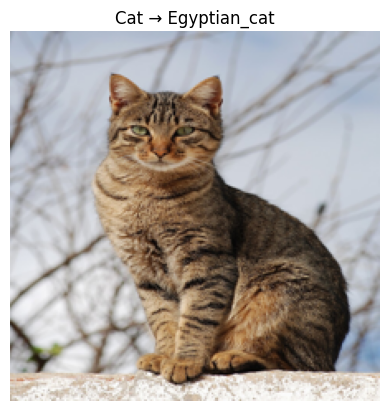

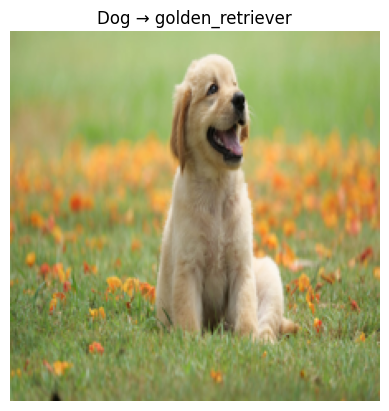

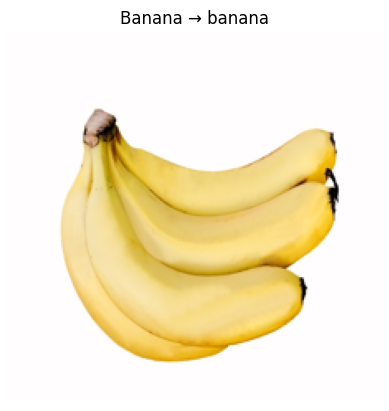

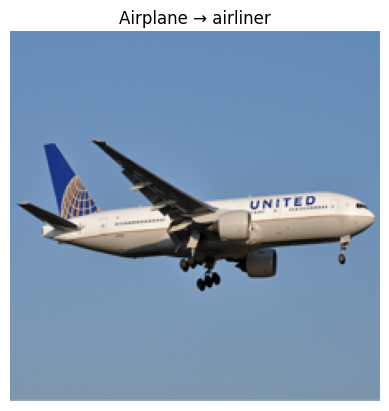

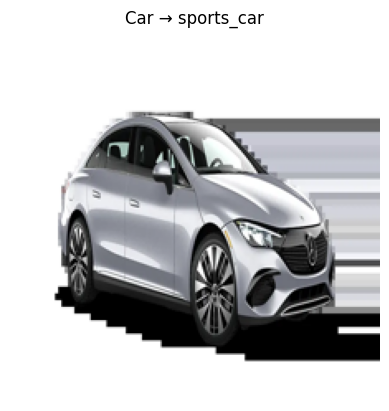

In [45]:
import matplotlib.pyplot as plt

for i in range(len(images)):
    plt.imshow(images[i])
    plt.title(f"{names[i]} → {decoded[i][0][1]}")
    plt.axis("off")
    plt.show()

### Record Your Results

Fill the table below based on your results:

| Image File   | Predicted Label | True Label (What you searched) | Correct? (Yes/No) |
| ------------ | --------------- | ------------------------------ | ----------------- |
|     Cat      | Egyptian_cat    |     Cat                        | Yes               |
|     Dog      | golden_retriever|     Dog                        | Yes               |
|    Banana    | banana          |     Banana                     | Yes               |
|   Airplane   | airliner        |     Airplane                   | Yes               |
|     Car      | sports_car      |     Car                        | Yes               |
